Лабораторна робота № 10

Тема. Стиснення даних. Жадібна стратегія на прикладі кодування Гафмена

Мета: навчитись реалізовувати алгоритм побудови дерева оптимальних кодів Гафмена на основі черги з пріоритетом (за допомогою купи) засобами Python.

Хід роботи:

Завдання на самостійну роботу

− Побудувати дерево кодів Гафмена згідно з варіантом, виданим викладачем вручну і візуалізувати дерево.

− Перевірити результат за допомогою коду, наведеному вище.

− Написати процедуру на Python, яка для вхідного повідомлення обчислює список символів chars та список їх частот freq

− Опрацювати самостійно тему декодування Гафмена і скориставшись наведеним там кодом, декодувати повідомлення, задане варіантом.

Chars: ['h', 'u', 'f', 'm', 'a', 'n', ' ', 'e', 'x', 'p', 'l', 's', 'g']
Freq : [1, 1, 2, 3, 3, 1, 2, 4, 1, 1, 1, 2, 1]


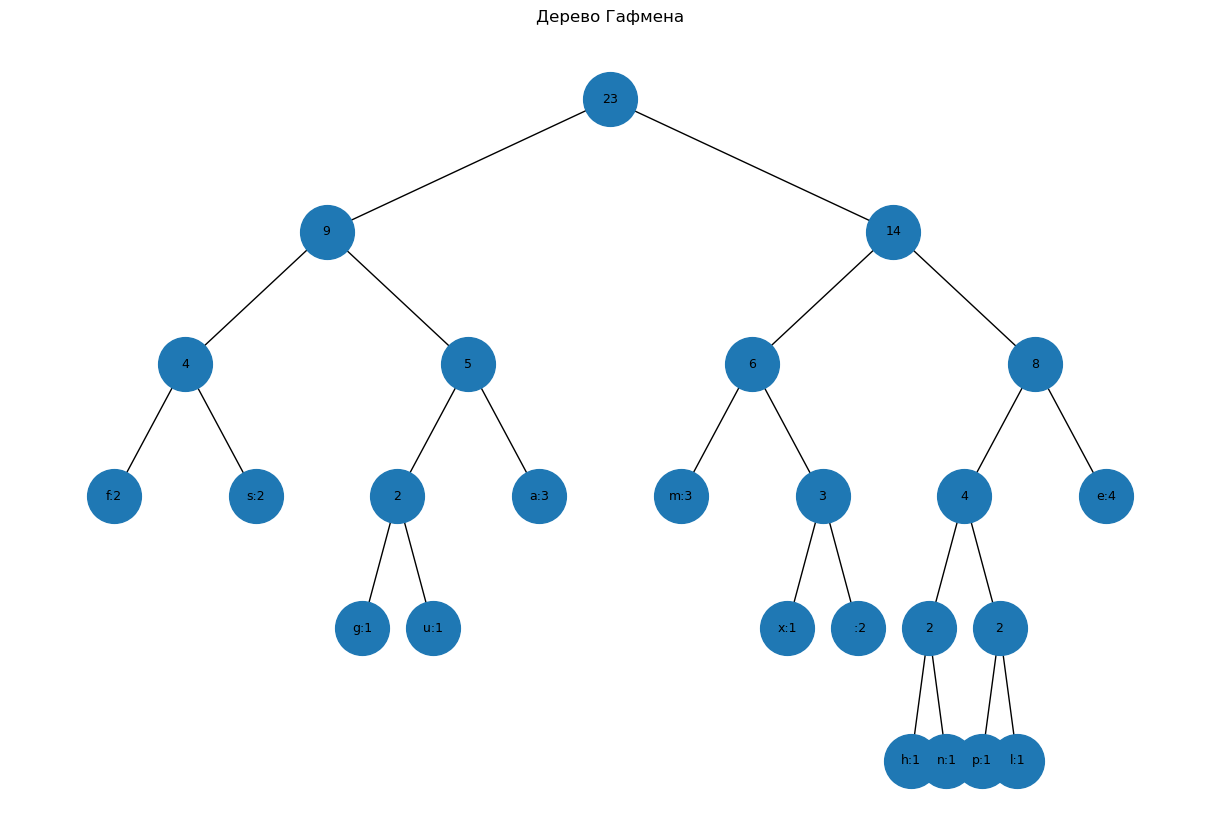

In [2]:
from collections import Counter

def get_chars_and_freq(message):
    counter = Counter(message)
    chars = list(counter.keys())
    freq = list(counter.values())
    return chars, freq

import heapq

class Node:
    def __init__(self, char=None, freq=0, left=None, right=None):
        self.char = char
        self.freq = freq
        self.left = left
        self.right = right

    def __lt__(self, other):
        return self.freq < other.freq


def build_huffman_tree(chars, freq):
    heap = []

    for c, f in zip(chars, freq):
        heapq.heappush(heap, Node(c, f))

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)

        merged = Node(None, left.freq + right.freq, left, right)
        heapq.heappush(heap, merged)

    return heap[0]


import networkx as nx
import matplotlib.pyplot as plt


def build_graph(G, node):
    if node is None:
        return
    if node.left:
        G.add_edge(node, node.left)
        build_graph(G, node.left)
    if node.right:
        G.add_edge(node, node.right)
        build_graph(G, node.right)


def get_positions(node, x=0, y=0, pos=None, dx=1.0):

    if pos is None:
        pos = {}

    pos[node] = (x, y)

    if node.left:
        pos = get_positions(node.left, x - dx, y - 1, pos, dx / 2)
    if node.right:
        pos = get_positions(node.right, x + dx, y - 1, pos, dx / 2)

    return pos


def visualize_huffman_tree(root):
    G = nx.DiGraph()
    build_graph(G, root)

    pos = get_positions(root, dx=4)

    labels = {}
    for node in G.nodes():
        if node.char is None:
            labels[node] = f"{node.freq}"
        else:
            labels[node] = f"{node.char}:{node.freq}"

    plt.figure(figsize=(12, 8))

    nx.draw(G, pos, with_labels=False, arrows=False, node_size=1500)
    nx.draw_networkx_labels(G, pos, labels, font_size=9)

    plt.title("Дерево Гафмена")
    plt.axis("off")
    plt.show()


message = "huffman example message"

chars, freq = get_chars_and_freq(message)
print("Chars:", chars)
print("Freq :", freq)

root = build_huffman_tree(chars, freq)

visualize_huffman_tree(root)

Контрольні питання:

1.Що таке жадібні алгоритми?

Жадібні алгоритми - це клас алгоритмів, які будують розв’язок поступово, роблячи на кожному кроці локально оптимальний вибір, сподіваючись, що в підсумку він приведе до глобально оптимального результату.

2.Що таке префіксний код? Який код використовується у коді Гафмена?

Префіксний код — це такий код, у якому жодне кодове слово не є префіксом іншого. Код Гафмена завжди є префіксним кодом.

3.Як пов’язана структура даних «купа» зі структурою даних «черга з пріоритетами»?

Черга з пріоритетами - це абстрактна структура даних, але сама по собі черга з пріоритетами — лише концепція. Її треба реалізувати за допомогою якоїсь внутрішньої структури. Купа - це структура, яка дозволяє ефективно реалізувати пріоритетну чергу.

4.Що таке стиснення даних і для чого воно використовується? Які його основні переваги?

Стиснення даних - це процес перетворення даних у форму, яка займає менше місця в пам’яті або передається швидше по мережі. Стиснення може бути з втратами або без втрат, залежно від того, чи можливо відновити вихідні дані повністю. Стиснення застосовується для: зменшення обсягів збереження, прискорення передачі даних, ефективність роботи програм. Основні переваги стиснення: менший обсяг даних, швидша передача по мережі, економія ресурсів, оптимізація продуктивності, можливість безпечної передачі.

5.Які кроки необхідно виконати для стиснення даних за допомогою алгоритму кодування Гафмена?

1. Підрахувати частоти символів
2. Створити вузли дерева для кожного символу
3. Побудувати дерево Гафмена
4. Присвоїти коди символам
5. Закодувати повідомлення
6. (Опційно) Зберегти або передати дерево

6.Які основні обмеження та недоліки алгоритму кодування Гафмена? Чи можливо покращити його продуктивність?

Основні обмеження та недоліки:

1. Символи з фіксованою частотою
2. Неефективний для маленьких повідомлень
3. Обов’язкова передача або зберігання дерева
4. Символи кодуються по одному
5. Неможливість прямого паралельного кодування

Можливі покращення продуктивності: Динамічне кодування Гафмена, кодування груп символів, комбінація з іншими алгоритмами, використання таблиць для швидкого пошуку.

7.Які існують альтернативні методи стиснення даних, що можуть конкурувати з алгоритмом Гафмена?

Алгоритми на основі словників, алгоритми зі статистичним/ентропійним кодуванням, алгоритми для специфічних типів даних, комбіновані алгоритми.

8.Які практичні застосування можуть мати алгоритми стиснення даних, зокрема алгоритм Гафмена, у сучасних інформаційних системах?

Архівування та зберігання файлів, передача даних по мережі, формати мультимедіа, бази даних та великі дані, програмне та системне забезпечення, потокові та реального часу системи, алгоритми стиснення як частина більших рішень.